In [60]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


## CARGA DE DATOS Y PRIMERA VISIÓN DEL CONJUNTO

In [61]:
# Cargamos el dataset final de tintos. 

df = pd.read_csv("/Users/josetudela/Projects/vinos_grupo2/Proyecto_grupo2_vinos/FINAL_DF_TINTOS.csv")

In [62]:
#Info
df.shape

(20158, 20)

In [63]:
#Info
df.T.head

<bound method NDFrame.head of                                                                   0      \
Url                   https://www.vivino.com/ES/es/crealto-pionda/w/...   
ID                                                              3105259   
Nombre                                                           Pionda   
Año                                                                2018   
País                                                             Italia   
Región                                                       Monferrato   
Bodega                                                          Crealto   
Tipo de vino                                                 Vino tinto   
Uva                                                            Nebbiolo   
Precio                                                            32.53   
Valoración                                                          3.8   
Contenido de alcohol                                                  

## TRATAMIENTO DE DATOS PARA TENER EL DATASET LIMPIO Y CON LA ESTRUCTURA BUSCADA

In [64]:
# Modificamos maridaje porque contiene una "," en medio de la descrpción 

def limpiar_caza(texto):
    if isinstance(texto, str) and "caza" in texto.lower():  # Verifica si es texto y contiene "caza"
        return pd.Series(texto).replace(r"\s*\(.*?\)", "", regex=True).iloc[0]
    return texto  # Devuelve el texto sin cambios si no tiene "caza"

# Aplicar la limpieza a todas las celdas del DataFrame
df = df.applymap(limpiar_caza)

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/211680032.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpiar_caza)


In [65]:
# Modificamos maridaje porque contiene una "," en medio de la descrpción 
def limpiar_pesca(texto):
    if isinstance(texto, str) and "azul " in texto.lower():  # Verifica si es texto y contiene "caza"
        return pd.Series(texto).replace(r"\s*\(.*?\)", "", regex=True).iloc[0]
    return texto  # Devuelve el texto sin cambios si no tiene "caza"

# Aplicar la limpieza a todas las celdas del DataFrame
df = df.applymap(limpiar_pesca)

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/979100320.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpiar_pesca)


In [66]:
#Info
df.T

,0,1,2,3,4,5,6,7,8,9,...,20148,20149,20150,20151,20152,20153,20154,20155,20156,20157
Url,https://www.vivino.com/ES/es/crealto-pionda/w/...,https://www.vivino.com/ES/es/karpatska-perla-v...,https://www.vivino.com/ES/es/giachino-giac-pot...,https://www.vivino.com/ES/es/pelz-pinot-nero/w...,https://www.vivino.com/ES/es/finca-la-capilla-...,https://www.vivino.com/ES/es/suertes-del-marqu...,https://www.vivino.com/ES/es/attis-el-molinero...,https://www.vivino.com/ES/es/tenuta-ormanni-bo...,https://www.vivino.com/ES/es/alta-alella-orbus...,https://www.vivino.com/ES/es/chateau-combel-la...,...,https://www.vivino.com/ES/es/tommasi-le-prunee...,https://www.vivino.com/ES/es/milesi-poderi-le-...,https://www.vivino.com/ES/es/avgvstvs-cabernet...,https://www.vivino.com/ES/es/banfi-col-di-sass...,https://www.vivino.com/ES/es/covitoro-canus-ve...,https://www.vivino.com/ES/es/cantina-di-santad...,https://www.vivino.com/ES/es/es-nueva-crianza/...,https://www.vivino.com/ES/es/campestral-especi...,https://www.vivino.com/ES/es/portal-del-monsta...,https://www.vivino.com/ES/es/es-prohom-experie...
ID,3105259,1280319,6365197,2573275,1133110,5985946,6343332,1302561,2735037,3985319,...,7090,2608984,1692307,22913,1134541,17967,1210509,11571930,1437498,5731154
Nombre,Pionda,Varieto Frankovka Modrá,Giac' Potes,Pinot Nero,La Capilla Vendimia Seleccionada,Cruz Santa,El Molinero,Borro del Diavolo Riserva Chianti Classico,Orbus,Le Lac-aux-Cochons Cahors,...,Le Pruneé Merlot,Poderi le Cinte Curtefranca Rosso,Cabernet Sauvignon - Merlot,Col di Sasso (Cabernet Sauvignon - Sangiovese),Cañus Verus Viñas Viejas,Grotta Rossa Carignano del Sulcis,Crianza,Especial Tinto,Santes Negre Sustainable Vineyards,Prohom Experientia Negre
Año,2018,2021,2023,2020,2021,2020,2018,2021,2021,2021,...,2020,2022,2021,2022,2020,2022,2018,2020,No disponible,2021
País,Italia,Eslovaquia,Francia,Italia,España,España,España,Italia,España,Francia,...,Italia,Italia,España,Italia,España,Italia,España,España,España,España
Región,Monferrato,Malokarpatská,Savoie,Vigneti delle Dolomiti,Ribera del Duero,Valle de la Orotava,Rías Baixas,Chianti Classico,Alella,Cahors,...,delle Venezie,Curtefranca,Penedès,Toscana,Toro,Carignano del Sulcis,Rioja,Vino de España,Montsant,Terra Alta
Bodega,Crealto,Karpatská Perla,Domaine Giachino,Pelz,Finca La Capilla,Suertes del Marqués,Attis,Ormanni,Alta Alella,Château Combel La Serre,...,Tommasi,Milesi,Avgvstvs,Banfi,Covitoro,Santadi,Finca Nueva,Campestral,Portal del Montsant,Coma d'En Bonet
Tipo de vino,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,...,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto
Uva,Nebbiolo,Blaufränkisch,"Gamay, Mondeuse Noire",Pinot Nero,Tinta del Pais,Vijariego Negro,Pinot Meunier,Sangiovese,Shiraz/Syrah,Malbec,...,Merlot,No disponible,"Cabernet Sauvignon, Merlot",Sangiovese,Tinta de toro,Carignan,Tempranillo,"Tintilla de Rota, Shiraz/Syrah, Cabernet Sauvi...",Ull de Llebre,"Shiraz/Syrah, Cabernet Sauvignon, Cariñena, Ga..."
Precio,32.53,32.52,32.52,32.50,32.50,32.50,32.50,32.50,32.50,32.50,...,10.88,10.88,10.88,10.86,9,12.40,10.85,10.85,8.51,10.85


In [67]:
#info
df.dtypes

Url                     object
ID                      object
Nombre                  object
Año                     object
País                    object
Región                  object
Bodega                  object
Tipo de vino            object
Uva                     object
Precio                  object
Valoración              object
Contenido de alcohol    object
Maridajes               object
Ligero/Poderoso         object
Suave/Tánico            object
Seco/Dulce              object
Débil/Ácido             object
Taste_Note_1            object
Taste_Note_2            object
Taste_Note_3            object
dtype: object

In [68]:
#Separamos la columna maridajes para que cada una sea una característica
df_maridaje_separado =  df["Maridajes"].str.split(',', expand=True)
df_maridaje_separado["ID"]= df["ID"]
df_maridaje_separado

,0,1,2,3,4,5,ID
0,Ternera,Cordero,Aves,Carne de caza,None,None,3105259
1,Ternera,Cordero,Aves,Carne de caza,None,None,1280319
2,Ternera,Carne de caza,Queso curado,Queso tierno y cremoso,None,None,6365197
3,Ternera,Ternera lechal,Aves,Carne de caza,None,None,2573275
4,Ternera,Cordero,Carne de caza,None,None,None,1133110
...,...,...,...,...,...,...,...
20153,Ternera,Cordero,Pasta,None,None,None,17967
20154,Ternera,Cordero,Ternera lechal,Aves,None,None,1210509
20155,Ternera,Ternera lechal,Aves,Pasta,None,None,11571930
20156,Ternera,Cordero,Pasta,None,None,None,1437498


In [69]:
# vemos los valores únicos para poder hacer one hot encoding. 
valores_unicos_maridaje = set(df_maridaje_separado.drop(columns=["ID"]).values.ravel())
print(valores_unicos_maridaje)

{'Carne de caza', 'Ternera', ' La comida basura vale', ' Ternera lechal', ' Cerdo', 'Maridajes', ' Queso tierno y cremoso', ' Pasta', ' Cordero', ' Aperitivos y tentempiés', 'No disponible', None, ' Comida picante', 'Aves', 'Ternera lechal', ' Pescado azul', ' Aves', ' Queso azul', ' Queso de leche de cabra', ' Champiñones', ' Carne adobada', 'Cordero', ' Carne de caza', ' Queso curado', ' Vegetariana', 'Cerdo', 'Pasta', ' Pescado blanco'}


In [70]:
#Info
len(valores_unicos_maridaje)

28

In [90]:
# Excluir la columna "ID" si está presente
df_maridaje_separado_sin_ID = df_maridaje_separado.drop(columns=["ID"]) if "ID" in df_maridaje_separado.columns else df_maridaje_separado

# Aplicar One-Hot Encoding
df_maridaje_one_hot_encoded = pd.get_dummies(df_maridaje_separado_sin_ID)
df_maridaje_one_hot_encoded["ID"] = df_maridaje_separado["ID"]

print(df_maridaje_one_hot_encoded.T.head())

                 0      1      2      3      4      5      6      7      \
0_Aves           False  False  False  False  False  False  False  False   
0_Carne de caza  False  False  False  False  False  False  False  False   
0_Cerdo          False  False  False  False  False  False  False  False   
0_Cordero        False  False  False  False  False  False  False  False   
0_Maridajes      False  False  False  False  False  False  False  False   

                 8      9      ...  20148  20149  20150  20151  20152  20153  \
0_Aves           False  False  ...  False  False  False  False  False  False   
0_Carne de caza  False  False  ...  False  False  False  False  False  False   
0_Cerdo          False  False  ...  False  False  False  False  False  False   
0_Cordero        False  False  ...  False  False  False  False  False  False   
0_Maridajes      False  False  ...  False  False  False  False  False  False   

                 20154  20155  20156  20157  
0_Aves           False

In [ ]:
#Separamos las notas de sabor en columnas diferentes. 

df_taste_1_separado = df["Taste_Note_1"].str.split(',', expand=True)
df_taste_1_separado["ID"] = df

,0,1,2
0,Terroso,cuero,virutas...
1,cereza,frutos rojos,None
2,fresa,frambuesa,cerez...
3,No disponible,None,None
4,ciruela,fruta negra,c...
...,...,...,...
20153,Terroso,cuero,humo
20154,roble,vainilla,tabaco
20155,No disponible,None,None
20156,fruta negra,mora,arán...


In [72]:
#Separamos las notas de sabor en columnas diferentes. 

df_taste_2_separado = df["Taste_Note_2"].str.split(',', expand=True)
df_taste_2_separado

,0,1,2
0,fresa,cereza,arándano...
1,Terroso,piedra,None
2,casis,mora,fruta negr...
3,No disponible,None,None
4,roble,vainilla,tabaco
...,...,...,...
20153,cereza,frutos rojos,f...
20154,cereza,frutos rojos,c...
20155,No disponible,None,None
20156,cereza,frambuesa,fres...


In [73]:
#Separamos las notas de sabor en columnas diferentes. 

df_taste_3_separado = df["Taste_Note_3"].str.split(',', expand=True)
df_taste_3_separado

,0,1,2
0,frutos del bosque,merm...,None
1,chocolate,tabaco,vain...
2,Terroso,minerales,cue...
3,No disponible,None,None
4,cuero,Terroso,ceniza
...,...,...,...
20153,roble,chocolate,tabac...
20154,mora,cereza negra,cir...
20155,No disponible,None,None
20156,Terroso,carne a la par...,None


In [76]:
#Método "casero" para unir todas la notas de sabor separadas en un solo df
df_taste_1_separado[3] = df_taste_2_separado[0]
df_taste_1_separado[4] = df_taste_2_separado[1]
df_taste_1_separado[5] = df_taste_2_separado[2]
df_taste_1_separado[6] = df_taste_3_separado[0]
df_taste_1_separado[7] = df_taste_3_separado[1]
df_taste_1_separado[8] = df_taste_3_separado[2]
df_taste_1_separado["ID"] = df["ID"]
df_taste_1_separado


,0,1,2,3,4,5,6,7,8,ID
0,Terroso,cuero,virutas...,fresa,cereza,arándano...,frutos del bosque,merm...,None,3105259
1,cereza,frutos rojos,None,Terroso,piedra,None,chocolate,tabaco,vain...,1280319
2,fresa,frambuesa,cerez...,casis,mora,fruta negr...,Terroso,minerales,cue...,6365197
3,No disponible,None,None,No disponible,None,None,No disponible,None,None,2573275
4,ciruela,fruta negra,c...,roble,vainilla,tabaco,cuero,Terroso,ceniza,1133110
...,...,...,...,...,...,...,...,...,...,...
20153,Terroso,cuero,humo,cereza,frutos rojos,f...,roble,chocolate,tabac...,17967
20154,roble,vainilla,tabaco,cereza,frutos rojos,c...,mora,cereza negra,cir...,1210509
20155,No disponible,None,None,No disponible,None,None,No disponible,None,None,11571930
20156,fruta negra,mora,arán...,cereza,frambuesa,fres...,Terroso,carne a la par...,None,1437498


In [77]:
df_taste_1_separado_tijera = df_taste_1_separado.applymap(lambda x: None if isinstance(x, str) and x.endswith('.') else x)
df_taste_1_separado_tijera

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/2875308546.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_taste_1_separado_tijera = df_taste_1_separado.applymap(lambda x: None if isinstance(x, str) and x.endswith('.') else x)


,0,1,2,3,4,5,6,7,8,ID
0,Terroso,cuero,None,fresa,cereza,None,frutos del bosque,None,None,3105259
1,cereza,frutos rojos,None,Terroso,piedra,None,chocolate,tabaco,None,1280319
2,fresa,frambuesa,None,casis,mora,None,Terroso,minerales,None,6365197
3,No disponible,None,None,No disponible,None,None,No disponible,None,None,2573275
4,ciruela,fruta negra,None,roble,vainilla,tabaco,cuero,Terroso,ceniza,1133110
...,...,...,...,...,...,...,...,...,...,...
20153,Terroso,cuero,humo,cereza,frutos rojos,None,roble,chocolate,None,17967
20154,roble,vainilla,tabaco,cereza,frutos rojos,None,mora,cereza negra,None,1210509
20155,No disponible,None,None,No disponible,None,None,No disponible,None,None,11571930
20156,fruta negra,mora,None,cereza,frambuesa,None,Terroso,None,None,1437498


In [80]:
df_taste_1_separado_tijera_sin_ID = df_taste_1_separado_tijera.drop(columns="ID")

In [81]:
# Obtener los valores únicos y su frecuencia para todo el DataFrame
valores_unicos_df_taste = df_taste_1_separado_tijera_sin_ID.values.ravel()  # Convierte el DataFrame en un array plano
conteo_valores_unicos_taste = pd.Series(valores_unicos_df_taste).value_counts()

print(conteo_valores_unicos_taste)

roble                     9954
cereza                    8019
 vainilla                 6762
cuero                     5861
 Terroso                  4964
                          ... 
mandarina                    1
azúcar quemada               1
 madreselva                  1
algodón de azúcar            1
pimienta rosa en grano       1
Name: count, Length: 503, dtype: int64


In [39]:
print((conteo_valores_unicos_taste >1).sum())

413


In [40]:
a=10
conteo_valores_unicos_taste_serie = [(conteo_valores_unicos_taste>i).sum() for i in range(a)]
conteo_valores_unicos_taste_serie

[np.int64(503),
 np.int64(413),
 np.int64(367),
 np.int64(330),
 np.int64(295),
 np.int64(274),
 np.int64(261),
 np.int64(245),
 np.int64(232),
 np.int64(226)]

In [41]:
mayor_que = list(range(0,a))
mayor_que

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Text(0.5, 1.0, 'palabras unicas vs filtro por > que')

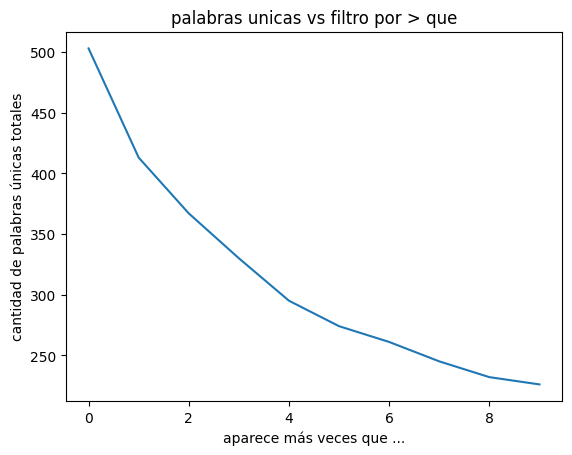

In [42]:
#Gráfico para apoyarnos si queremos eliminar palabras únicas que se repitan poco

plt.plot(mayor_que,conteo_valores_unicos_taste_serie,)
plt.xlabel('aparece más veces que ...')
plt.ylabel('cantidad de palabras únicas totales')
plt.title('palabras unicas vs filtro por > que')

In [92]:


# Aplicar One-Hot Encoding
df_taste_1_one_hot_encoded = pd.get_dummies(df_taste_1_separado_tijera_sin_ID)
df_taste_1_one_hot_encoded["ID"] = df_taste_1_separado["ID"]
print(df_taste_1_one_hot_encoded.head)

<bound method NDFrame.head of        0_Carne adobada  0_Carne de caza  0_No disponible  \
0                False            False            False   
1                False            False            False   
2                False            False            False   
3                False            False             True   
4                False            False            False   
...                ...              ...              ...   
20153            False            False            False   
20154            False            False            False   
20155            False            False             True   
20156            False            False            False   
20157            False            False            False   

       0_Polvo de 5 especias  0_Terroso  0_aceite  0_aceituna negra  \
0                      False       True     False             False   
1                      False      False     False             False   
2                      False      Fa

In [96]:
df_merged_one_hot = pd.concat([df.set_index("ID"), df_maridaje_one_hot_encoded.set_index("ID"), df_taste_1_one_hot_encoded.set_index("ID")], axis=1).reset_index()

print(df_merged_one_hot.head())

        ID                                                Url  \
0  3105259  https://www.vivino.com/ES/es/crealto-pionda/w/...   
1  1280319  https://www.vivino.com/ES/es/karpatska-perla-v...   
2  6365197  https://www.vivino.com/ES/es/giachino-giac-pot...   
3  2573275  https://www.vivino.com/ES/es/pelz-pinot-nero/w...   
4  1133110  https://www.vivino.com/ES/es/finca-la-capilla-...   

                             Nombre   Año        País                  Región  \
0                            Pionda  2018      Italia              Monferrato   
1           Varieto Frankovka Modrá  2021  Eslovaquia           Malokarpatská   
2                       Giac' Potes  2023     Francia                  Savoie   
3                        Pinot Nero  2020      Italia  Vigneti delle Dolomiti   
4  La Capilla Vendimia Seleccionada  2021      España        Ribera del Duero   

             Bodega Tipo de vino                    Uva Precio  ...  \
0           Crealto   Vino tinto               Nebb

In [99]:
for i in df_merged_one_hot.columns:
    print (i)

ID
Url
Nombre
Año
País
Región
Bodega
Tipo de vino
Uva
Precio
Valoración
Contenido de alcohol
Maridajes
Ligero/Poderoso
Suave/Tánico
Seco/Dulce
Débil/Ácido
Taste_Note_1
Taste_Note_2
Taste_Note_3
0_Aves
0_Carne de caza
0_Cerdo
0_Cordero
0_Maridajes
0_No disponible
0_Pasta
0_Ternera
0_Ternera lechal
1_ Aperitivos y tentempiés
1_ Aves
1_ Carne adobada
1_ Carne de caza
1_ Cerdo
1_ Cordero
1_ Queso curado
1_ Ternera lechal
1_ Vegetariana
2_ Aves
2_ Carne de caza
2_ Cerdo
2_ Champiñones
2_ Pasta
2_ Pescado azul
2_ Queso curado
2_ Ternera lechal
2_ Vegetariana
3_ Aperitivos y tentempiés
3_ Aves
3_ Carne adobada
3_ Carne de caza
3_ Cerdo
3_ Champiñones
3_ Pasta
3_ Pescado blanco
3_ Queso azul
3_ Queso curado
3_ Queso de leche de cabra
3_ Queso tierno y cremoso
3_ Vegetariana
4_ Aperitivos y tentempiés
4_ Aves
4_ Carne adobada
4_ Carne de caza
4_ Champiñones
4_ Comida picante
4_ La comida basura vale
4_ Queso curado
4_ Queso de leche de cabra
4_ Queso tierno y cremoso
5_ Carne adobada
5_ Queso a